In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv('lsd_math_score_data.csv')

In [3]:
print(data)

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score
0                      5     1.17                78.93
1                     15     2.97                58.20
2                     30     3.26                67.47
3                     60     4.69                37.47
4                    120     5.83                45.65
5                    240     6.00                32.92
6                    480     6.41                29.97


In [4]:
type(data)

pandas.core.frame.DataFrame

In [5]:
math_scores = data['Avg_Math_Test_Score']
print(math_scores)

0    78.93
1    58.20
2    67.47
3    37.47
4    45.65
5    32.92
6    29.97
Name: Avg_Math_Test_Score, dtype: float64


In [6]:
# Adding new Column along with temp data
data['TestSubjects'] = 'Jennifer Lopez' 
print(data) 

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score    TestSubjects
0                      5     1.17                78.93  Jennifer Lopez
1                     15     2.97                58.20  Jennifer Lopez
2                     30     3.26                67.47  Jennifer Lopez
3                     60     4.69                37.47  Jennifer Lopez
4                    120     5.83                45.65  Jennifer Lopez
5                    240     6.00                32.92  Jennifer Lopez
6                    480     6.41                29.97  Jennifer Lopez


In [7]:
data['HighScore'] = 100
print(data)

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score    TestSubjects  \
0                      5     1.17                78.93  Jennifer Lopez   
1                     15     2.97                58.20  Jennifer Lopez   
2                     30     3.26                67.47  Jennifer Lopez   
3                     60     4.69                37.47  Jennifer Lopez   
4                    120     5.83                45.65  Jennifer Lopez   
5                    240     6.00                32.92  Jennifer Lopez   
6                    480     6.41                29.97  Jennifer Lopez   

   HighScore  
0        100  
1        100  
2        100  
3        100  
4        100  
5        100  
6        100  


In [8]:
# Adding scores to 100 and showing as if they are highscores 
data['HighScore'] +=data['Avg_Math_Test_Score']
print(data)

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score    TestSubjects  \
0                      5     1.17                78.93  Jennifer Lopez   
1                     15     2.97                58.20  Jennifer Lopez   
2                     30     3.26                67.47  Jennifer Lopez   
3                     60     4.69                37.47  Jennifer Lopez   
4                    120     5.83                45.65  Jennifer Lopez   
5                    240     6.00                32.92  Jennifer Lopez   
6                    480     6.41                29.97  Jennifer Lopez   

   HighScore  
0     178.93  
1     158.20  
2     167.47  
3     137.47  
4     145.65  
5     132.92  
6     129.97  


In [9]:
type(math_scores)

pandas.core.series.Series

In [10]:
cleanData = data[['LSD_ppm','Avg_Math_Test_Score']]
print(cleanData)
type(cleanData)

   LSD_ppm  Avg_Math_Test_Score
0     1.17                78.93
1     2.97                58.20
2     3.26                67.47
3     4.69                37.47
4     5.83                45.65
5     6.00                32.92
6     6.41                29.97


pandas.core.frame.DataFrame

In [11]:
y = data[['Avg_Math_Test_Score']] #provided List so we get DataFrame
type(y)

pandas.core.frame.DataFrame

In [12]:
y = data['Avg_Math_Test_Score'] #provided String we get Series
type(y)

pandas.core.series.Series

In [13]:
X = data[['LSD_ppm']]
print(X)
type(X)

   LSD_ppm
0     1.17
1     2.97
2     3.26
3     4.69
4     5.83
5     6.00
6     6.41


pandas.core.frame.DataFrame

In [14]:
del data['TestSubjects']
print(data)

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score  HighScore
0                      5     1.17                78.93     178.93
1                     15     2.97                58.20     158.20
2                     30     3.26                67.47     167.47
3                     60     4.69                37.47     137.47
4                    120     5.83                45.65     145.65
5                    240     6.00                32.92     132.92
6                    480     6.41                29.97     129.97


In [15]:
del data['HighScore']
print(data)

   Time_Delay_in_Minutes  LSD_ppm  Avg_Math_Test_Score
0                      5     1.17                78.93
1                     15     2.97                58.20
2                     30     3.26                67.47
3                     60     4.69                37.47
4                    120     5.83                45.65
5                    240     6.00                32.92
6                    480     6.41                29.97


In [16]:
time = data[['Time_Delay_in_Minutes']]
LSD = data[['LSD_ppm']]
score = data[['Avg_Math_Test_Score']]

In [17]:
type(LSD)

pandas.core.frame.DataFrame

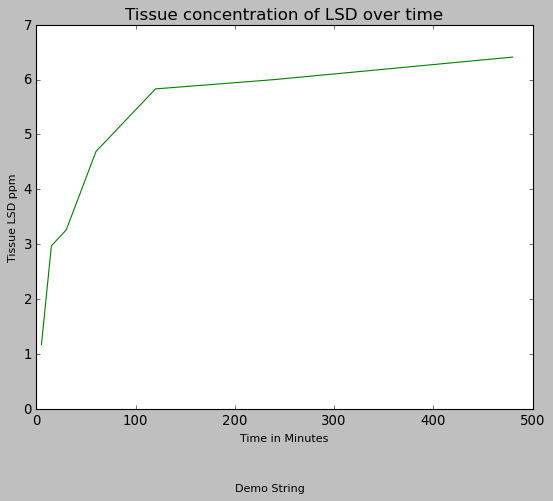

In [110]:
%matplotlib inline

plt.title('Tissue concentration of LSD over time', fontsize=15)

plt.xlabel('Time in Minutes', fontsize=10)
plt.ylabel('Tissue LSD ppm', fontsize=10)

plt.text(x=200,y=-1.5, s='Demo String', fontsize=10)
plt.ylim(0,7)
plt.xlim(0,500)

plt.style.use('classic')

plt.plot(time, LSD, color='g')
plt.show()

In [123]:
regr = LinearRegression()
regr.fit(LSD, score)
print("Theta 1: ",regr.coef_[0][0])
print("Intercept: ",regr.intercept_[0])
print("R-square: ",regr.score(LSD,score))

predictedScore = regr.predict(LSD)

Theta 1:  -9.009466415296785
Intercept:  89.12387376799308
R-square:  0.8778349707775889


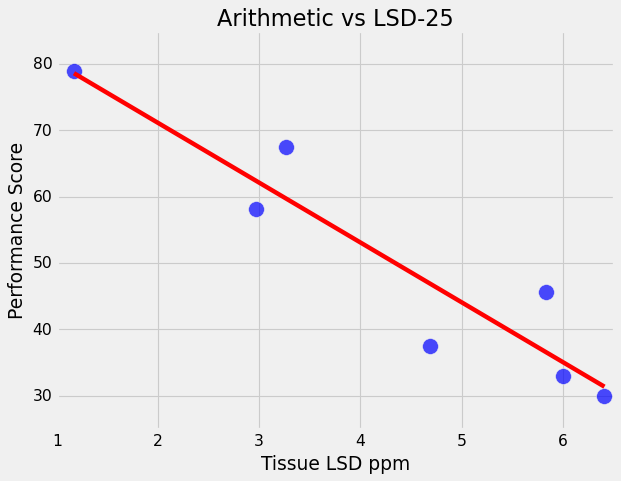

In [129]:
%matplotlib inline

plt.scatter(LSD, score, s=200 ,alpha=0.7 )

plt.title("Arithmetic vs LSD-25")
plt.xlabel("Tissue LSD ppm")
plt.ylabel("Performance Score")

plt.xlim(1,6.5)
plt.ylim(25,85)

plt.style.use('fivethirtyeight')
plt.plot(LSD, predictedScore, color='red')
plt.show()